# Assignment 01

In [10]:
import pandas as pd
import os
import numpy as np

## Check for Missing Values

In [4]:
def check_missing_values(df: pd.DataFrame, df_name: str = "DataFrame"):

    if df.empty:
        print(f"\nWarning: {df_name} is empty. Cannot perform missing value check.")
        return

    
    separator_length = 60
    print("\n" + "="*separator_length)
   
    print(f"## Detailed Missing Value Check in {df_name}")
    print("="*separator_length)

   
    missing_values = df.isnull().sum()
    
    missing_values = missing_values[missing_values > 0]

    if missing_values.empty:
        print(f"No missing (NaN) values found in the {df_name}.")
    else:
        print(f"Missing values found for the following variables in {df_name}:")
        print("\nColumn Name | NaN Count")
        print("--------------------|----------")
        
        for column, count in missing_values.sort_values(ascending=False).items():
            print(f"{column.ljust(18)}| {count}")

    print("="*separator_length)

## Check for Duplicates

In [5]:
def check_for_duplicates(df: pd.DataFrame, df_name: str, key: list):
  
    separator_length = 60
    print("\n" + "="*separator_length)
    print(f"## Duplicate Entry Check for: {df_name}")
    print(f"Key used: {key}")
    print("="*separator_length)

    if df.empty:
        print(f"Warning: {df_name} is empty. Skipping duplicate check.")
        return

    duplicate_rows = df[df.duplicated(subset=key, keep=False)]

    if duplicate_rows.empty:
        print(f"No duplicate entries found for the key {tuple(key)} in {df_name}.")
    else:
        num_duplicates = len(duplicate_rows)
       
        num_groups = num_duplicates - duplicate_rows.drop_duplicates(subset=key).shape[0]
        
        print(f"{num_duplicates} duplicate rows identified based on the key {tuple(key)}.")
        print(f"(These rows belong to {num_groups} unique sets of duplicate key values.)")
        
        print("\nSample of Duplicate Rows (showing all entries for the duplicated key):")
      
        print(duplicate_rows.sort_values(by=key).head())
        
    print("="*separator_length)

## Dataset: Food Demand Forecasting

| Criterion | Details |
|------------|----------|
| **Name of the Dataset** | Food Demand Forecasting Dataset |
| **Source (Link)** | [Kaggle: Food Demand Forecasting](https://www.kaggle.com/competitions/food-demand-forecasting) |
| **Description of Data Measures** | The data measures the weekly number of orders (demand) for specific center-meal combinations within a multi-city meal delivery company. The goal is to predict future demand to optimize the planning of perishable raw material stock and staffing at various fulfillment centers. |
| **Frequency of the Data** | Weekly. The raw material replenishment and forecasting task are structured around weekly intervals. |
| **Time Span Covered** | The available historical data (training set) covers an unspecified period, ending at Week 145. The competition task requires forecasting demand for the subsequent 10 weeks (Weeks 146–155). |


### Load dataset + merge

In [3]:
data_dir = '/kaggle/input/food-demand-forecasting' 

try:
    train_df = pd.read_csv(os.path.join(data_dir, 'train.csv'))
    test_df = pd.read_csv(os.path.join(data_dir, 'test.csv'))
    center_info_df = pd.read_csv(os.path.join(data_dir, 'fulfilment_center_info.csv'))
    meal_info_df = pd.read_csv(os.path.join(data_dir, 'meal_info.csv'))

    print("Dataframes loaded successfully!")
    print(f"Training data shape: {train_df.shape}")
    
   
    train_df = pd.merge(train_df, center_info_df, on='center_id', how='left')
    train_df = pd.merge(train_df, meal_info_df, on='meal_id', how='left')
    
    test_df = pd.merge(test_df, center_info_df, on='center_id', how='left')
    test_df = pd.merge(test_df, meal_info_df, on='meal_id', how='left')

    print("\nSample of Merged Training Data:")
    print(train_df.head())

except FileNotFoundError:
    print(f"\nError: Could not find files in the '{data_dir}' directory.")
    print("Please ensure the Kaggle API download command in Step 1 ran correctly.")

print (train_df.columns)

Dataframes loaded successfully!
Training data shape: (456548, 9)

Sample of Merged Training Data:
        id  week  center_id  meal_id  checkout_price  base_price  \
0  1379560     1         55     1885          136.83      152.29   
1  1466964     1         55     1993          136.83      135.83   
2  1346989     1         55     2539          134.86      135.86   
3  1338232     1         55     2139          339.50      437.53   
4  1448490     1         55     2631          243.50      242.50   

   emailer_for_promotion  homepage_featured  num_orders  city_code  \
0                      0                  0         177        647   
1                      0                  0         270        647   
2                      0                  0         189        647   
3                      0                  0          54        647   
4                      0                  0          40        647   

   region_code center_type  op_area   category cuisine  
0           56 

### Check for Missing Values

In [9]:
check_missing_values(train_df, df_name="Training Data")
check_missing_values(test_df, df_name="Test Data")


## Detailed Missing Value Check in Training Data
No missing (NaN) values found in the Training Data.

## Detailed Missing Value Check in Test Data
No missing (NaN) values found in the Test Data.


### Validate the Timestamp Sequence:

In [10]:
print("\n## Validate the Timestamp Sequence (Week Continuity)")


min_week = train_df['week'].min()
max_week = train_df['week'].max()
total_weeks = max_week - min_week + 1

print(f"Time Span Covered: Week {min_week} to Week {max_week}")
print(f"Total Unique Weeks Expected: {total_weeks}")

unique_weeks = train_df['week'].nunique()
print(f"Total Unique Weeks Found: {unique_weeks}")

if unique_weeks == total_weeks:
    print("All weeks (1 to 145) are present in the dataset (at least once).")
else:
    print(f"Warning: Missing week numbers in the overall time series. Expected {total_weeks}, found {unique_weeks}.")
    
# Check for internal series gaps (Are all weeks present for every center-meal combination?)
pivot_table = train_df.pivot_table(
    index=['center_id', 'meal_id'], 
    columns='week', 
    values='num_orders'
)

missing_weeks_per_series = pivot_table.isnull().sum(axis=1)
series_with_gaps = missing_weeks_per_series[missing_weeks_per_series > 0]

print(f"\nTotal unique center-meal combinations (time series): {len(pivot_table)}")
print(f"Number of series with missing weeks (internal gaps): {len(series_with_gaps)}")

if len(series_with_gaps) == 0:
    print("All unique center-meal combinations appear to have data for all weeks 1 to 145.")
else:
    print(f"Significant gaps found. {len(series_with_gaps)} out of {len(pivot_table)} series have missing weeks.")
    print("\nSample series with missing weeks (count of missing weeks):")
    print(series_with_gaps.head())
    print("\nThis means many (meal, center) combinations were not ordered for some weeks.")


## Validate the Timestamp Sequence (Week Continuity)
Time Span Covered: Week 1 to Week 145
Total Unique Weeks Expected: 145
Total Unique Weeks Found: 145
All weeks (1 to 145) are present in the dataset (at least once).

Total unique center-meal combinations (time series): 3597
Number of series with missing weeks (internal gaps): 2350
Significant gaps found. 2350 out of 3597 series have missing weeks.

Sample series with missing weeks (count of missing weeks):
center_id  meal_id
10         1207        1
           1216        2
           1247       23
           1438        2
           1525        8
dtype: int64

This means many (meal, center) combinations were not ordered for some weeks.


### Check for Duplicates

In [11]:
time_series_key = ['week', 'center_id', 'meal_id']


check_for_duplicates(train_df, "Merged Training Data", time_series_key)
check_for_duplicates(test_df, "Merged Test Data", time_series_key)


## Duplicate Entry Check for: Merged Training Data
Key used: ['week', 'center_id', 'meal_id']
No duplicate entries found for the key ('week', 'center_id', 'meal_id') in Merged Training Data.

## Duplicate Entry Check for: Merged Test Data
Key used: ['week', 'center_id', 'meal_id']
No duplicate entries found for the key ('week', 'center_id', 'meal_id') in Merged Test Data.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


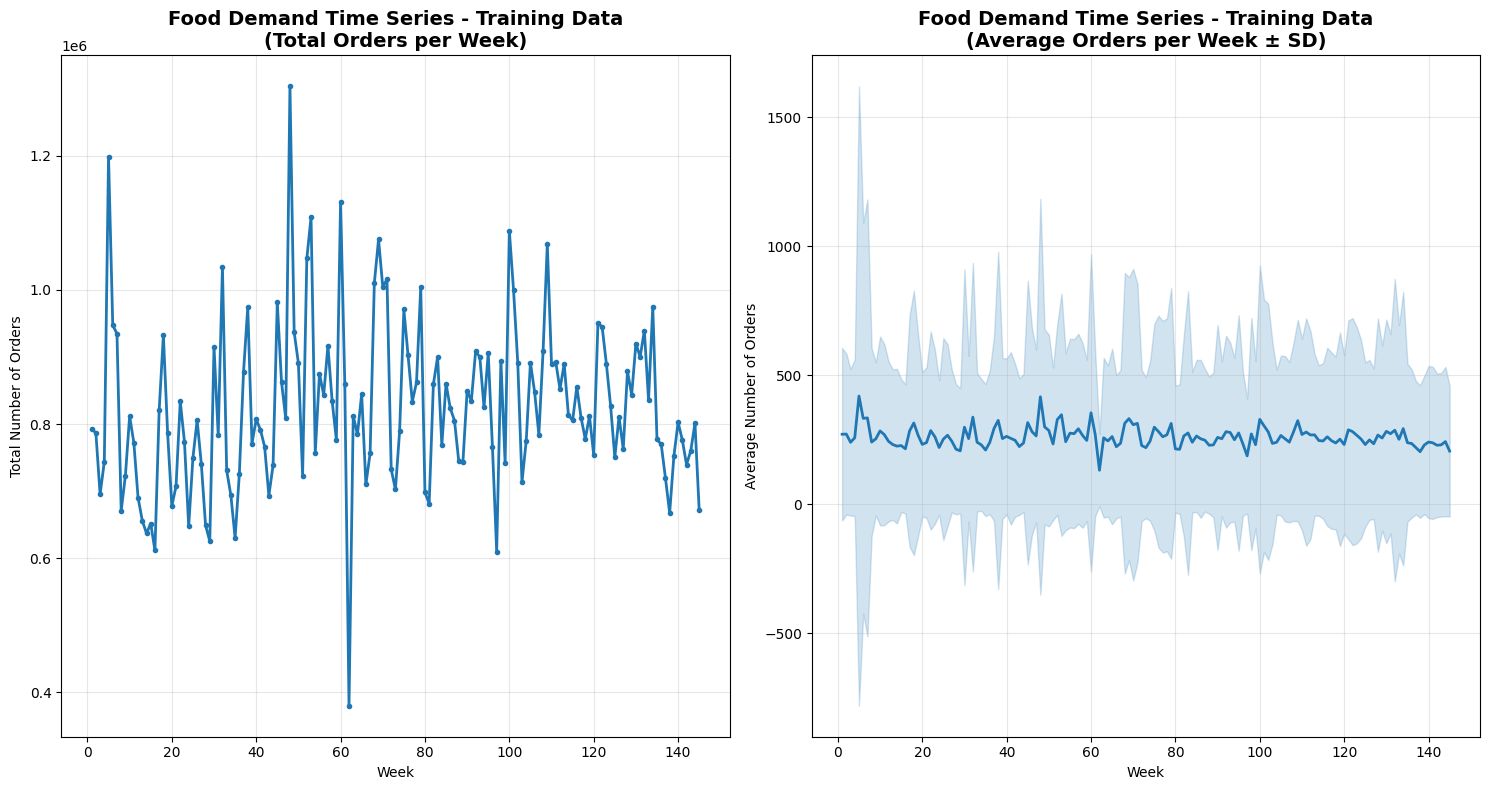

Time Range: Week 1 to Week 145
Total Orders: 119,557,485
Average Weekly Orders: 824534
Peak Week Orders: 1,303,457


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

def create_time_plot(df: pd.DataFrame, title: str = "Time Series Plot"):
    """
    Create a basic time plot with week on X-axis and num_orders on Y-axis
    """
    plt.figure(figsize=(15, 8))
    
    # Option 1: Aggregate total orders per week
    weekly_orders = df.groupby('week')['num_orders'].sum().reset_index()
    
    plt.subplot(1, 2, 1)
    plt.plot(weekly_orders['week'], weekly_orders['num_orders'], 
             linewidth=2, marker='o', markersize=3)
    plt.title(f'{title}\n(Total Orders per Week)', fontsize=14, fontweight='bold')
    plt.xlabel('Week')
    plt.ylabel('Total Number of Orders')
    plt.grid(True, alpha=0.3)
    
    # Option 2: Show average orders per week with confidence interval
    plt.subplot(1, 2, 2)
    sns.lineplot(data=df, x='week', y='num_orders', 
                 errorbar='sd', linewidth=2)
    plt.title(f'{title}\n(Average Orders per Week ± SD)', fontsize=14, fontweight='bold')
    plt.xlabel('Week')
    plt.ylabel('Average Number of Orders')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print some statistics
    print(f"Time Range: Week {df['week'].min()} to Week {df['week'].max()}")
    print(f"Total Orders: {weekly_orders['num_orders'].sum():,}")
    print(f"Average Weekly Orders: {weekly_orders['num_orders'].mean():.0f}")
    print(f"Peak Week Orders: {weekly_orders['num_orders'].max():,}")

# Create time plots for training data
create_time_plot(train_df, "Food Demand Time Series - Training Data")

## Basic Time Series Analysis


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


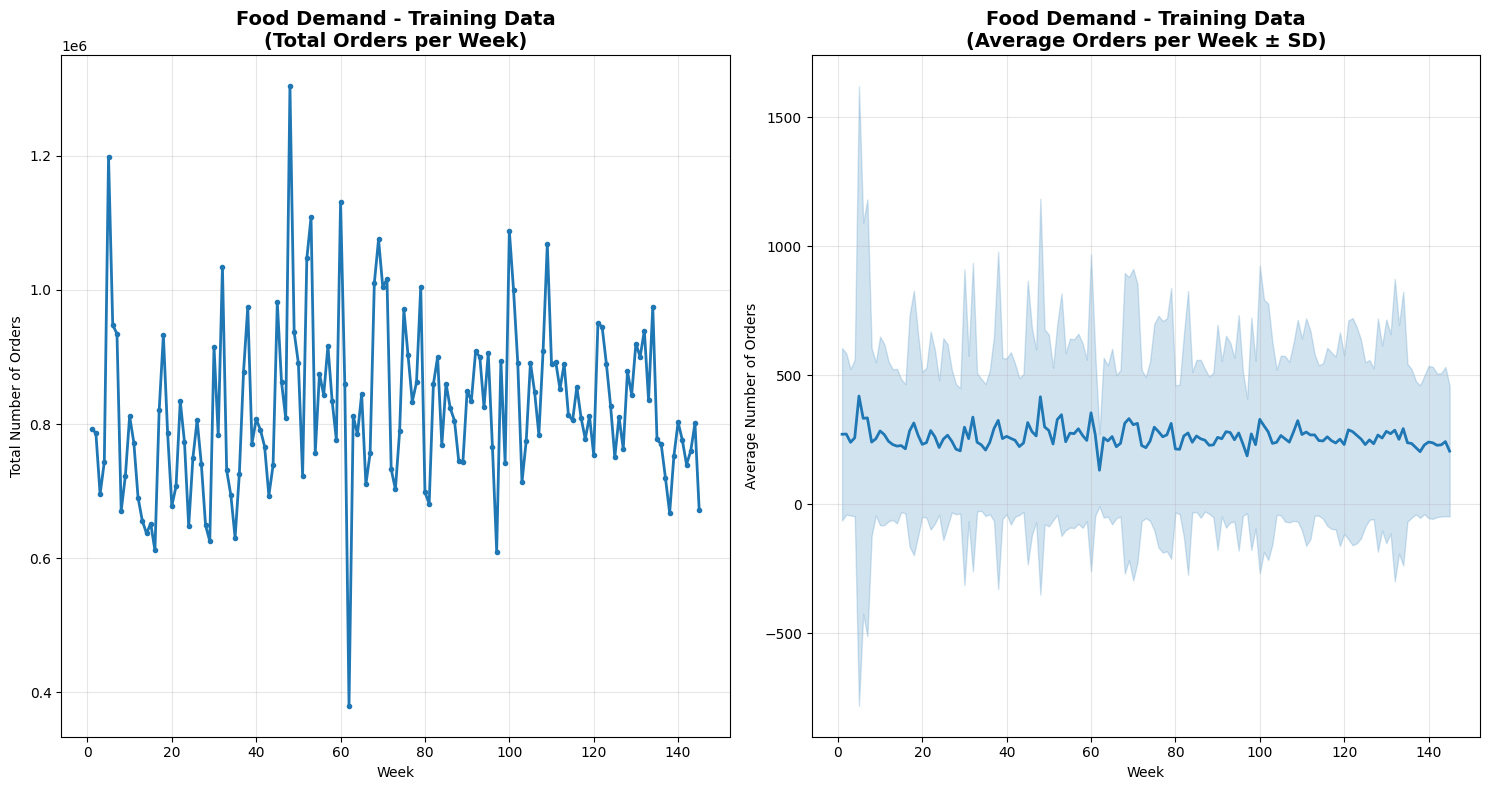

Time Range: Week 1 to Week 145
Total Orders: 119,557,485
Average Weekly Orders: 824534
Peak Week Orders: 1,303,457

## Category-wise Time Series


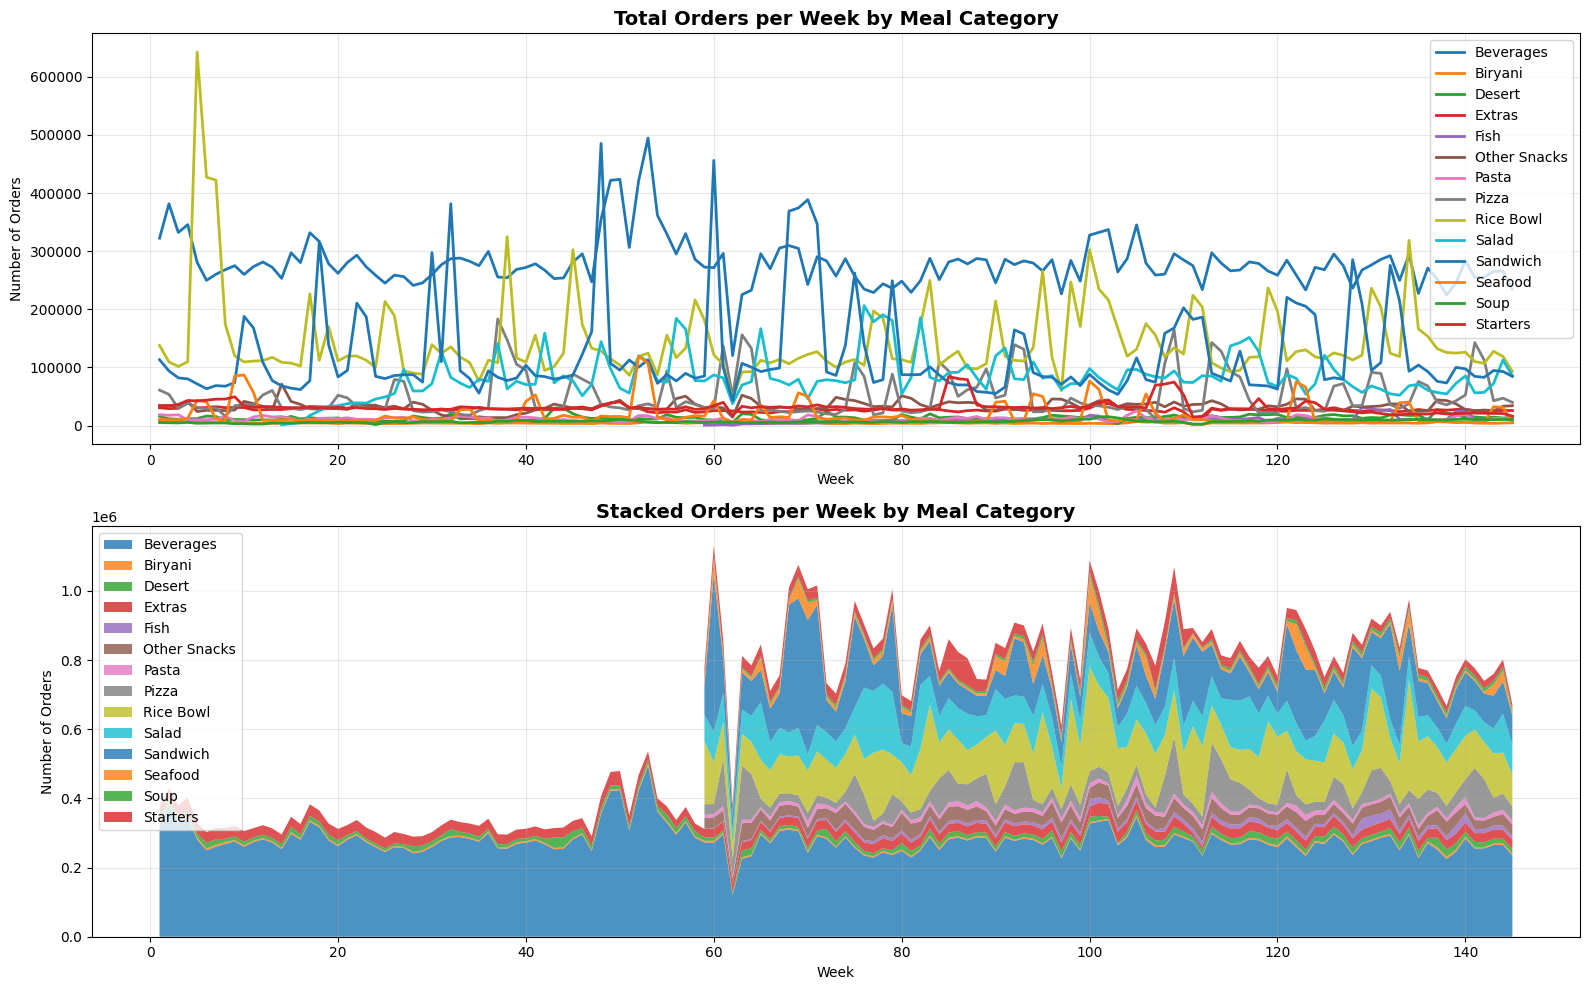


## Smoothed Time Series (Trend Analysis)


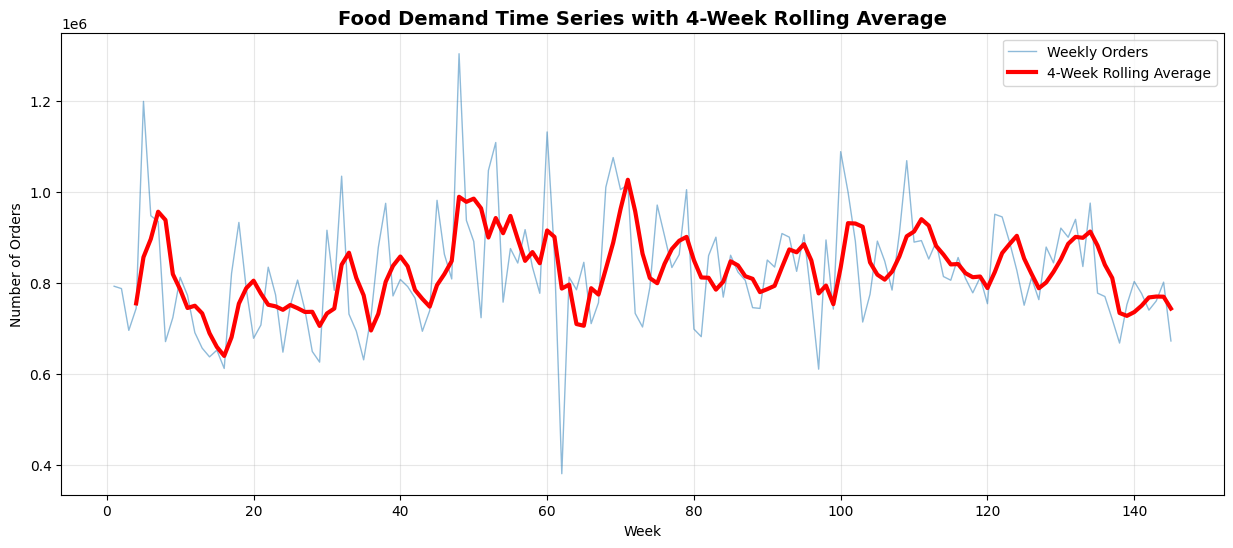

In [5]:
# Option 3: Time plot by category
def create_time_plot_by_category(df: pd.DataFrame):
    """
    Create time plots grouped by meal category
    """
    plt.figure(figsize=(16, 10))
    
    # Aggregate by week and category
    category_weekly = df.groupby(['week', 'category'])['num_orders'].sum().reset_index()
    
    # Pivot for plotting
    pivot_data = category_weekly.pivot(index='week', columns='category', values='num_orders')
    
    plt.subplot(2, 1, 1)
    for category in pivot_data.columns:
        plt.plot(pivot_data.index, pivot_data[category], label=category, linewidth=2)
    
    plt.title('Total Orders per Week by Meal Category', fontsize=14, fontweight='bold')
    plt.xlabel('Week')
    plt.ylabel('Number of Orders')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Stacked area chart
    plt.subplot(2, 1, 2)
    plt.stackplot(pivot_data.index, pivot_data.T, labels=pivot_data.columns, alpha=0.8)
    plt.title('Stacked Orders per Week by Meal Category', fontsize=14, fontweight='bold')
    plt.xlabel('Week')
    plt.ylabel('Number of Orders')
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Option 4: Time plot with rolling average
def create_smoothed_time_plot(df: pd.DataFrame, window: int = 4):
    """
    Create time plot with rolling average to see trends more clearly
    """
    plt.figure(figsize=(15, 6))
    
    weekly_orders = df.groupby('week')['num_orders'].sum().reset_index()
    
    # Calculate rolling average
    weekly_orders['rolling_avg'] = weekly_orders['num_orders'].rolling(window=window).mean()
    
    plt.plot(weekly_orders['week'], weekly_orders['num_orders'], 
             alpha=0.5, label='Weekly Orders', linewidth=1)
    plt.plot(weekly_orders['week'], weekly_orders['rolling_avg'], 
             color='red', linewidth=3, label=f'{window}-Week Rolling Average')
    
    plt.title(f'Food Demand Time Series with {window}-Week Rolling Average', 
              fontsize=14, fontweight='bold')
    plt.xlabel('Week')
    plt.ylabel('Number of Orders')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Execute all visualizations
print("## Basic Time Series Analysis")
create_time_plot(train_df, "Food Demand - Training Data")

print("\n## Category-wise Time Series")
create_time_plot_by_category(train_df)

print("\n## Smoothed Time Series (Trend Analysis)")
create_smoothed_time_plot(train_df, window=4)

Total weeks: 145
Pseudo years: [1 2 3]
## 1. SEASONAL PLOT: Year-over-Year Comparison


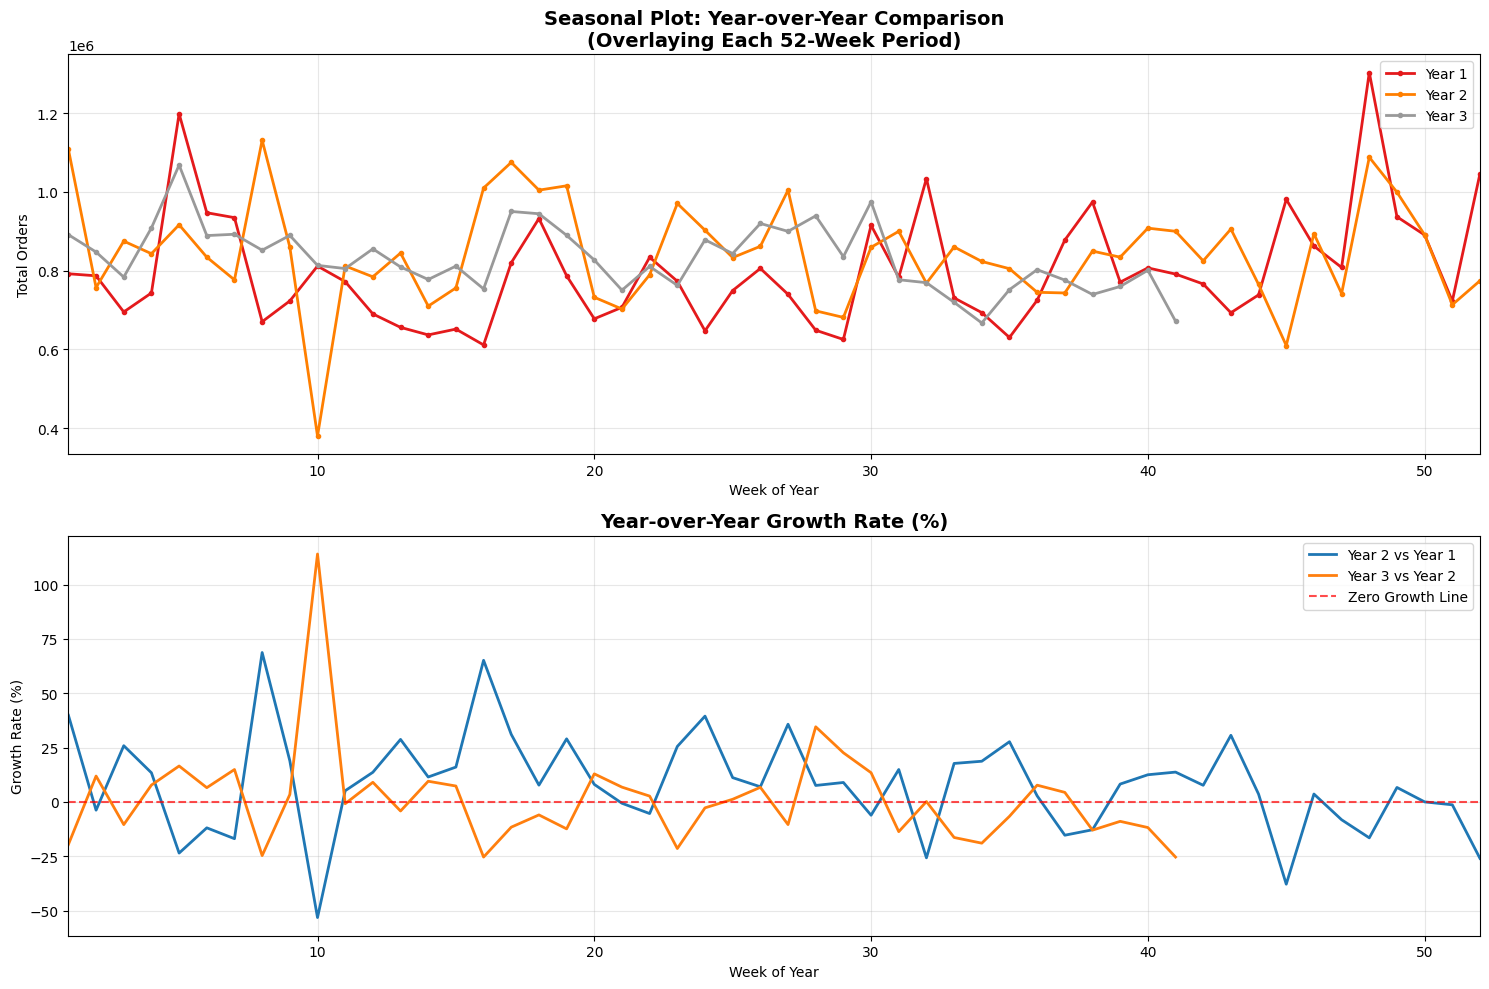


## 2. SEASONAL SUBSERIES PLOT: Quarterly Patterns


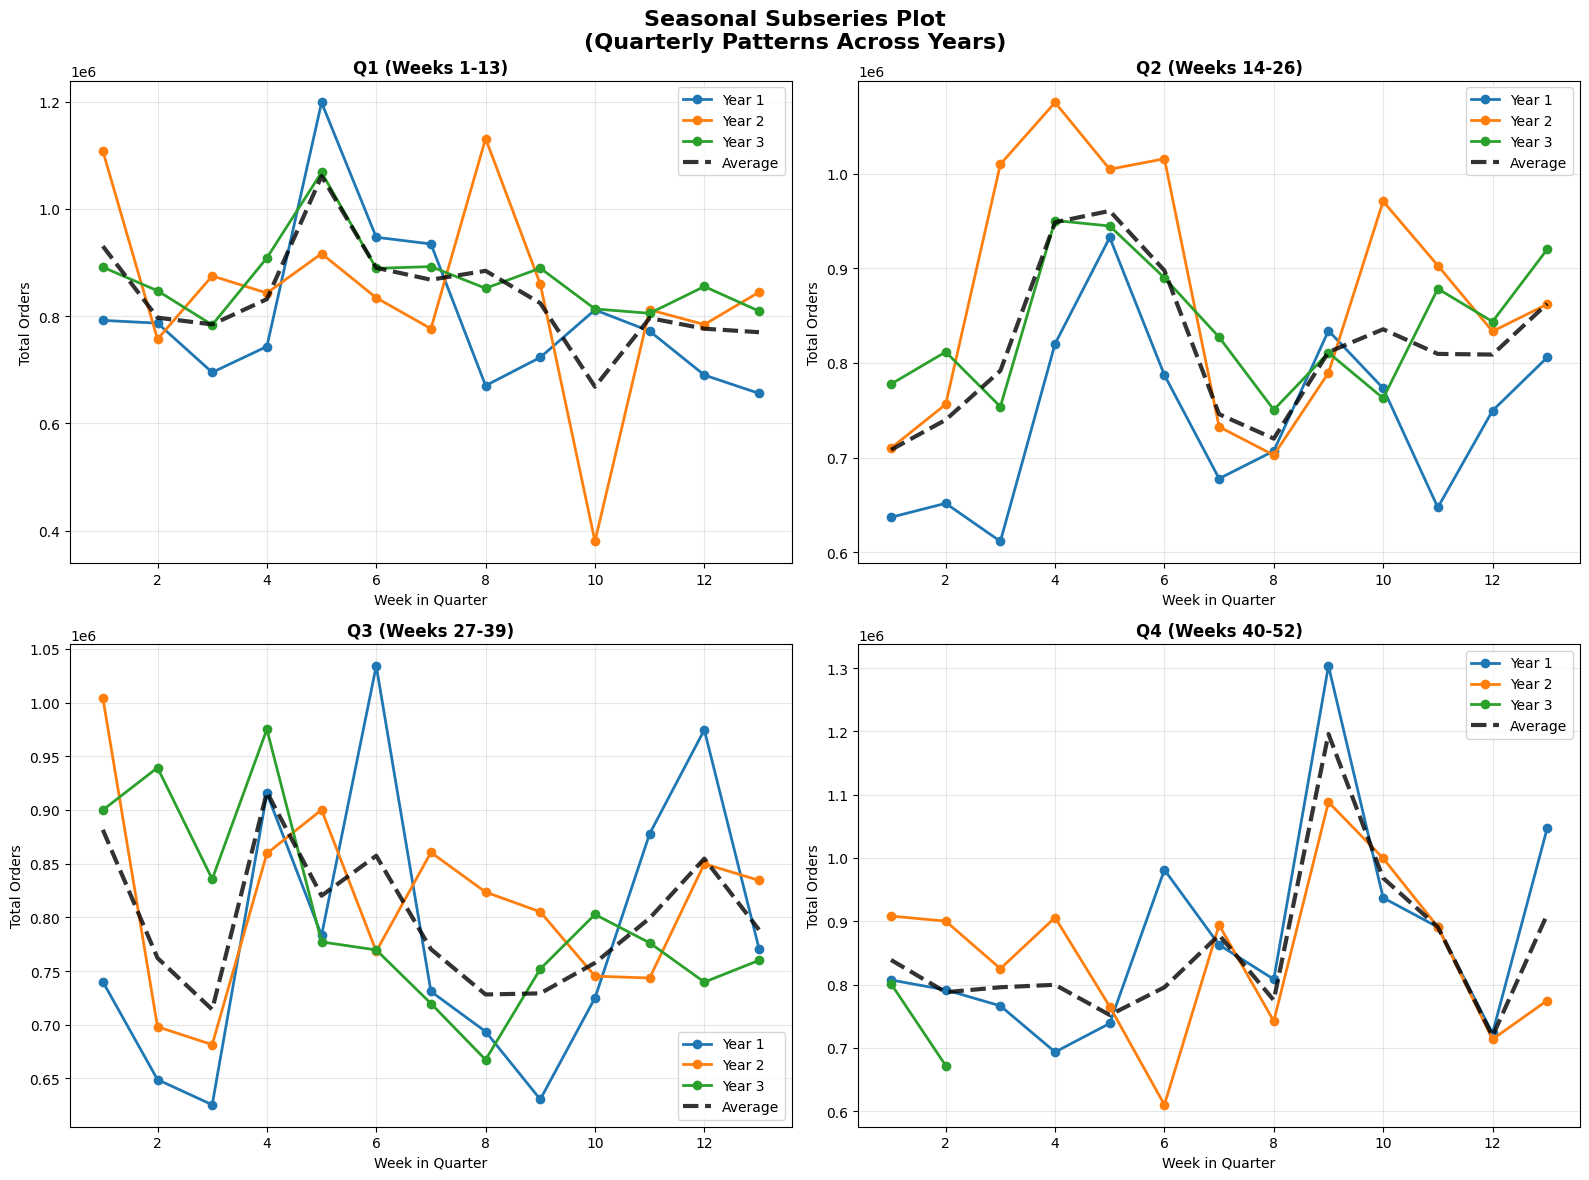


## 3. MONTHLY SEASONALITY ANALYSIS


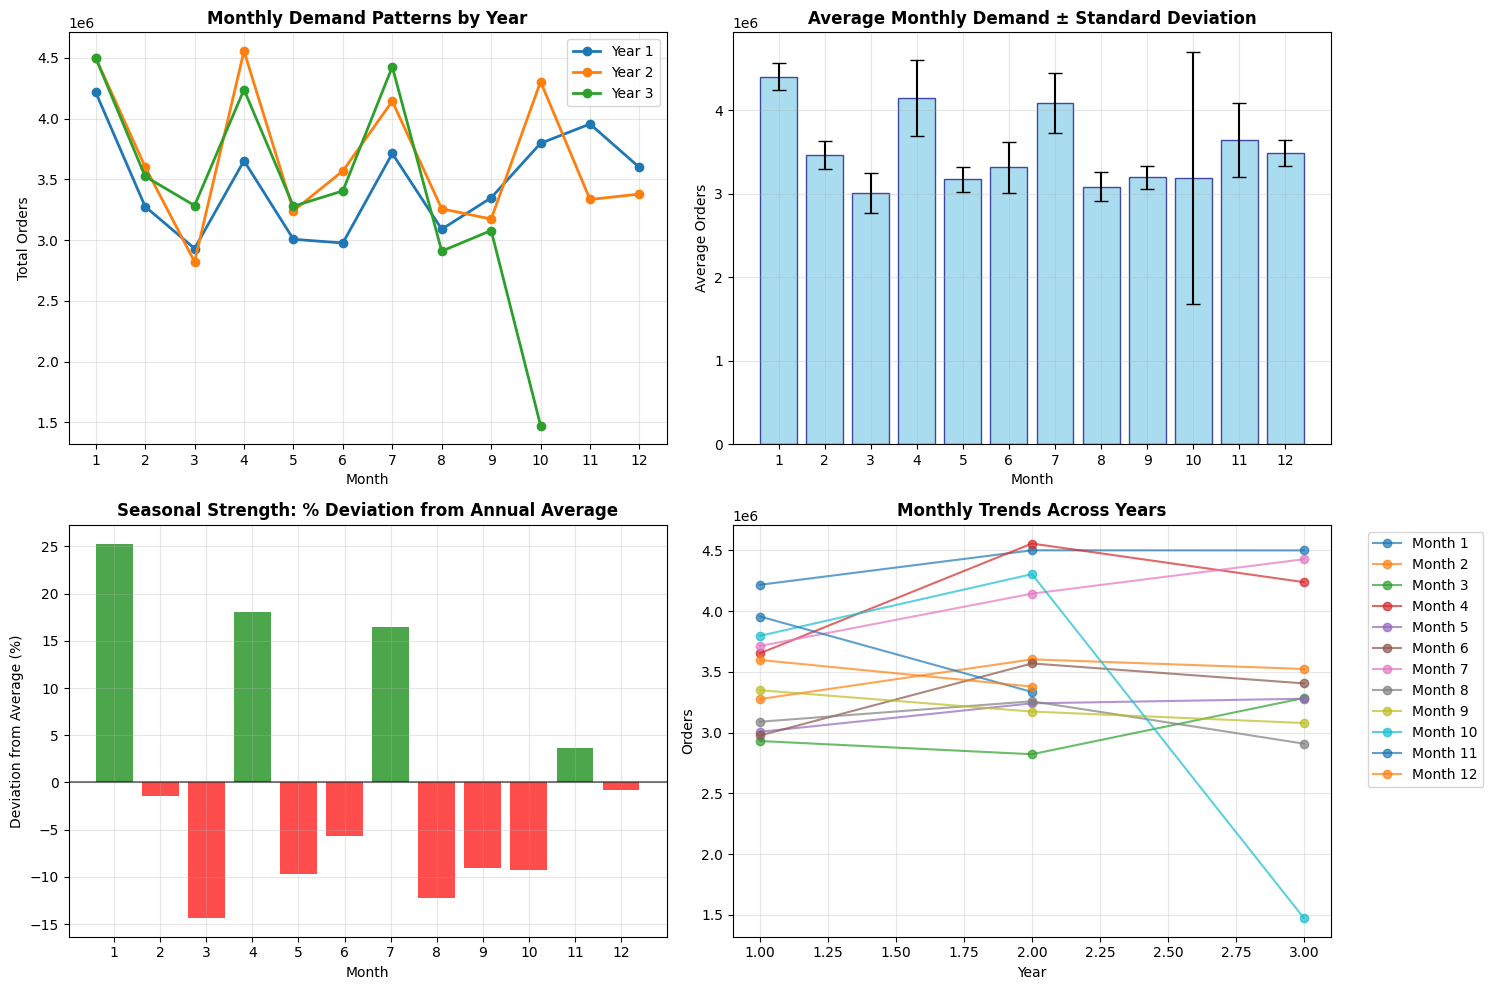


## 4. SEASONALITY INTERPRETATION SUMMARY
SEASONALITY ANALYSIS: KEY INSIGHTS

📈 SEASONAL PATTERN STABILITY:
• Pattern Stability: MODERATELY STABLE (Avg CV: 0.114)

📊 YEAR-OVER-YEAR TRENDS:
• Year 1 → Year 2: +5.6% growth
• Year 2 → Year 3: -22.3% growth

🗓️  MONTHLY SEASONALITY PATTERNS:
• Peak Demand: Month 1 (4405776 orders)
• Lowest Demand: Month 3 (3012029 orders)
• Seasonality Strength: 1.46x (peak vs trough)

📅 QUARTERLY PATTERNS:
• Q1: 837327 avg orders
• Q2: 818536 avg orders
• Q3: 798426 avg orders
• Q4: 851436 avg orders

💡 BUSINESS RECOMMENDATIONS:
• MILD seasonality → Focus on consistent operations
• Stable patterns → Reliable forecasting expected


In [11]:
# Part 2: In-Depth Seasonality Analysis

def create_seasonal_analysis(df, target_col='num_orders'):
    """
    Comprehensive seasonality analysis for weekly food demand data
    """
    
    # Create time-based features
    df_analysis = df.copy()
    
    # Aggregate to weekly level (if needed)
    weekly_data = df_analysis.groupby('week')[target_col].sum().reset_index()
    
    # Since we have 145 weeks, let's analyze:
    # - Weekly patterns (within year)
    # - "Year-over-year" comparison (treating each 52-week period as a "year")
    
    # Add pseudo-year and week-of-year
    weekly_data['pseudo_year'] = ((weekly_data['week'] - 1) // 52) + 1
    weekly_data['week_of_year'] = ((weekly_data['week'] - 1) % 52) + 1
    
    print(f"Total weeks: {len(weekly_data)}")
    print(f"Pseudo years: {weekly_data['pseudo_year'].unique()}")
    
    return weekly_data

# Prepare data for seasonality analysis
weekly_agg = create_seasonal_analysis(train_df)

# 1. SEASONAL PLOT (Year-over-Year Comparison)
def create_seasonal_plot(df, title="Seasonal Plot: Year-over-Year Comparison"):
    """
    Overlay corresponding periods (pseudo-years) on top of each other
    """
    plt.figure(figsize=(15, 10))
    
    # Get unique years
    years = sorted(df['pseudo_year'].unique())
    colors = plt.cm.Set1(np.linspace(0, 1, len(years)))
    
    plt.subplot(2, 1, 1)
    
    for i, year in enumerate(years):
        year_data = df[df['pseudo_year'] == year]
        plt.plot(year_data['week_of_year'], year_data['num_orders'], 
                label=f'Year {year}', color=colors[i], linewidth=2, marker='o', markersize=3)
    
    plt.title(f'{title}\n(Overlaying Each 52-Week Period)', fontsize=14, fontweight='bold')
    plt.xlabel('Week of Year')
    plt.ylabel('Total Orders')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xlim(1, 52)
    
    # 2. Highlight differences between years
    plt.subplot(2, 1, 2)
    
    # Calculate year-over-year growth
    pivot_data = df.pivot(index='week_of_year', columns='pseudo_year', values='num_orders')
    
    for year in years[1:]:  # Skip first year for YoY comparison
        prev_year = year - 1
        if prev_year in pivot_data.columns:
            yoy_growth = ((pivot_data[year] - pivot_data[prev_year]) / pivot_data[prev_year] * 100)
            plt.plot(yoy_growth.index, yoy_growth.values, 
                    label=f'Year {year} vs Year {prev_year}', linewidth=2)
    
    plt.axhline(y=0, color='red', linestyle='--', alpha=0.7, label='Zero Growth Line')
    plt.title('Year-over-Year Growth Rate (%)', fontsize=14, fontweight='bold')
    plt.xlabel('Week of Year')
    plt.ylabel('Growth Rate (%)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xlim(1, 52)
    
    plt.tight_layout()
    plt.show()
    
    return pivot_data

print("## 1. SEASONAL PLOT: Year-over-Year Comparison")
seasonal_data = create_seasonal_plot(weekly_agg)

# 2. SEASONAL SUBSERIES PLOT
def create_seasonal_subseries_plot(df, title="Seasonal Subseries Plot"):
    """
    Create subseries plot showing each season (month/quarter equivalent) separately
    """
    
    # Since we have weekly data, let's group into "seasons" (quarters of the year)
    df_seasonal = df.copy()
    df_seasonal['quarter'] = ((df_seasonal['week_of_year'] - 1) // 13) + 1
    df_seasonal['quarter_week'] = ((df_seasonal['week_of_year'] - 1) % 13) + 1
    
    quarters = sorted(df_seasonal['quarter'].unique())
    years = sorted(df_seasonal['pseudo_year'].unique())
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()
    
    quarter_names = {1: 'Q1 (Weeks 1-13)', 2: 'Q2 (Weeks 14-26)', 
                     3: 'Q3 (Weeks 27-39)', 4: 'Q4 (Weeks 40-52)'}
    
    for i, quarter in enumerate(quarters):
        if i < len(axes):
            quarter_data = df_seasonal[df_seasonal['quarter'] == quarter]
            
            # Plot each year's quarter pattern
            for year in years:
                year_quarter_data = quarter_data[quarter_data['pseudo_year'] == year]
                axes[i].plot(year_quarter_data['quarter_week'], 
                           year_quarter_data['num_orders'],
                           label=f'Year {year}', marker='o', linewidth=2)
            
            # Add mean line
            mean_by_week = quarter_data.groupby('quarter_week')['num_orders'].mean()
            axes[i].plot(mean_by_week.index, mean_by_week.values, 
                       color='black', linewidth=3, linestyle='--', 
                       label='Average', alpha=0.8)
            
            axes[i].set_title(f'{quarter_names[quarter]}', fontweight='bold')
            axes[i].set_xlabel('Week in Quarter')
            axes[i].set_ylabel('Total Orders')
            axes[i].legend()
            axes[i].grid(True, alpha=0.3)
    
    plt.suptitle(f'{title}\n(Quarterly Patterns Across Years)', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return df_seasonal

print("\n## 2. SEASONAL SUBSERIES PLOT: Quarterly Patterns")
subseries_data = create_seasonal_subseries_plot(weekly_agg)

# 3. MONTHLY SEASONALITY ANALYSIS (Approximate)
def create_monthly_seasonality(df, title="Monthly Seasonality Analysis"):
    """
    Analyze monthly patterns (approximated from weekly data)
    """
    df_monthly = df.copy()
    
    # Approximate months (4.33 weeks per month)
    df_monthly['month'] = ((df_monthly['week_of_year'] - 1) // 4.33) + 1
    df_monthly['month'] = df_monthly['month'].astype(int)
    df_monthly['month'] = df_monthly['month'].clip(1, 12)  # Ensure 12 months
    
    monthly_agg = df_monthly.groupby(['pseudo_year', 'month'])['num_orders'].sum().reset_index()
    
    plt.figure(figsize=(15, 10))
    
    # Monthly patterns by year
    plt.subplot(2, 2, 1)
    for year in monthly_agg['pseudo_year'].unique():
        year_data = monthly_agg[monthly_agg['pseudo_year'] == year]
        plt.plot(year_data['month'], year_data['num_orders'], 
                label=f'Year {year}', marker='o', linewidth=2)
    
    plt.title('Monthly Demand Patterns by Year', fontweight='bold')
    plt.xlabel('Month')
    plt.ylabel('Total Orders')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(range(1, 13))
    
    # Monthly averages
    plt.subplot(2, 2, 2)
    monthly_avg = monthly_agg.groupby('month')['num_orders'].mean()
    monthly_std = monthly_agg.groupby('month')['num_orders'].std()
    
    plt.bar(monthly_avg.index, monthly_avg.values, 
            yerr=monthly_std.values, capsize=5, alpha=0.7,
            color='skyblue', edgecolor='navy')
    plt.title('Average Monthly Demand ± Standard Deviation', fontweight='bold')
    plt.xlabel('Month')
    plt.ylabel('Average Orders')
    plt.grid(True, alpha=0.3)
    plt.xticks(range(1, 13))
    
    # Seasonality strength
    plt.subplot(2, 2, 3)
    overall_avg = monthly_agg['num_orders'].mean()
    seasonal_strength = ((monthly_avg - overall_avg) / overall_avg * 100)
    
    colors = ['red' if x < 0 else 'green' for x in seasonal_strength]
    plt.bar(seasonal_strength.index, seasonal_strength.values, color=colors, alpha=0.7)
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.5)
    plt.title('Seasonal Strength: % Deviation from Annual Average', fontweight='bold')
    plt.xlabel('Month')
    plt.ylabel('Deviation from Average (%)')
    plt.grid(True, alpha=0.3)
    plt.xticks(range(1, 13))
    
    # Monthly growth trends
    plt.subplot(2, 2, 4)
    monthly_pivot = monthly_agg.pivot(index='month', columns='pseudo_year', values='num_orders')
    
    for month in range(1, 13):
        month_data = monthly_pivot.loc[month]
        if len(month_data) > 1:
            plt.plot(month_data.index, month_data.values, 
                    marker='o', label=f'Month {month}', alpha=0.7)
    
    plt.title('Monthly Trends Across Years', fontweight='bold')
    plt.xlabel('Year')
    plt.ylabel('Orders')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return monthly_agg

print("\n## 3. MONTHLY SEASONALITY ANALYSIS")
monthly_data = create_monthly_seasonality(weekly_agg)

# 4. SEASONALITY INTERPRETATION SUMMARY
def print_seasonality_insights(seasonal_data, subseries_data, monthly_data):
    """
    Provide automated insights from seasonality analysis
    """
    print("="*70)
    print("SEASONALITY ANALYSIS: KEY INSIGHTS")
    print("="*70)
    
    # Seasonal Pattern Stability
    print("\n📈 SEASONAL PATTERN STABILITY:")
    
    # Calculate coefficient of variation for each week across years
    weekly_cv = seasonal_data.std(axis=1) / seasonal_data.mean(axis=1)
    avg_cv = weekly_cv.mean()
    
    if avg_cv < 0.1:
        stability = "VERY STABLE"
    elif avg_cv < 0.2:
        stability = "MODERATELY STABLE" 
    else:
        stability = "VOLATILE"
    
    print(f"• Pattern Stability: {stability} (Avg CV: {avg_cv:.3f})")
    
    # Year-over-Year Growth
    print("\n📊 YEAR-OVER-YEAR TRENDS:")
    yearly_totals = seasonal_data.sum()
    for i in range(1, len(yearly_totals)):
        growth = (yearly_totals.iloc[i] - yearly_totals.iloc[i-1]) / yearly_totals.iloc[i-1] * 100
        print(f"• Year {i} → Year {i+1}: {growth:+.1f}% growth")
    
    # Monthly Seasonality Insights
    print("\n🗓️  MONTHLY SEASONALITY PATTERNS:")
    monthly_avg = monthly_data.groupby('month')['num_orders'].mean()
    peak_month = monthly_avg.idxmax()
    trough_month = monthly_avg.idxmin()
    seasonality_ratio = monthly_avg.max() / monthly_avg.min()
    
    print(f"• Peak Demand: Month {peak_month} ({monthly_avg.max():.0f} orders)")
    print(f"• Lowest Demand: Month {trough_month} ({monthly_avg.min():.0f} orders)")
    print(f"• Seasonality Strength: {seasonality_ratio:.2f}x (peak vs trough)")
    
    # Quarterly Insights
    print("\n📅 QUARTERLY PATTERNS:")
    quarterly_avg = subseries_data.groupby('quarter')['num_orders'].mean()
    for qtr, avg_orders in quarterly_avg.items():
        print(f"• Q{qtr}: {avg_orders:.0f} avg orders")
    
    # Business Recommendations
    print("\n💡 BUSINESS RECOMMENDATIONS:")
    if seasonality_ratio > 1.5:
        print("• STRONG seasonality detected → Plan inventory and staffing for peak periods")
    else:
        print("• MILD seasonality → Focus on consistent operations")
    
    if avg_cv < 0.15:
        print("• Stable patterns → Reliable forecasting expected")
    else:
        print("• Volatile patterns → Use conservative forecasting with safety stock")

print("\n## 4. SEASONALITY INTERPRETATION SUMMARY")
print_seasonality_insights(seasonal_data, subseries_data, monthly_data)

AUTOCORRELATION ANALYSIS
Time series length: 145 weeks
Analysis lags: 52 (up to 1 year for weekly data)

Creating Lag Plots...

## 1. LAG PLOTS ANALYSIS
Interpreting lag plots:
• Tight scatter along diagonal = Strong autocorrelation
• Circular/random scatter = Weak autocorrelation
• Specific patterns = Non-linear relationships


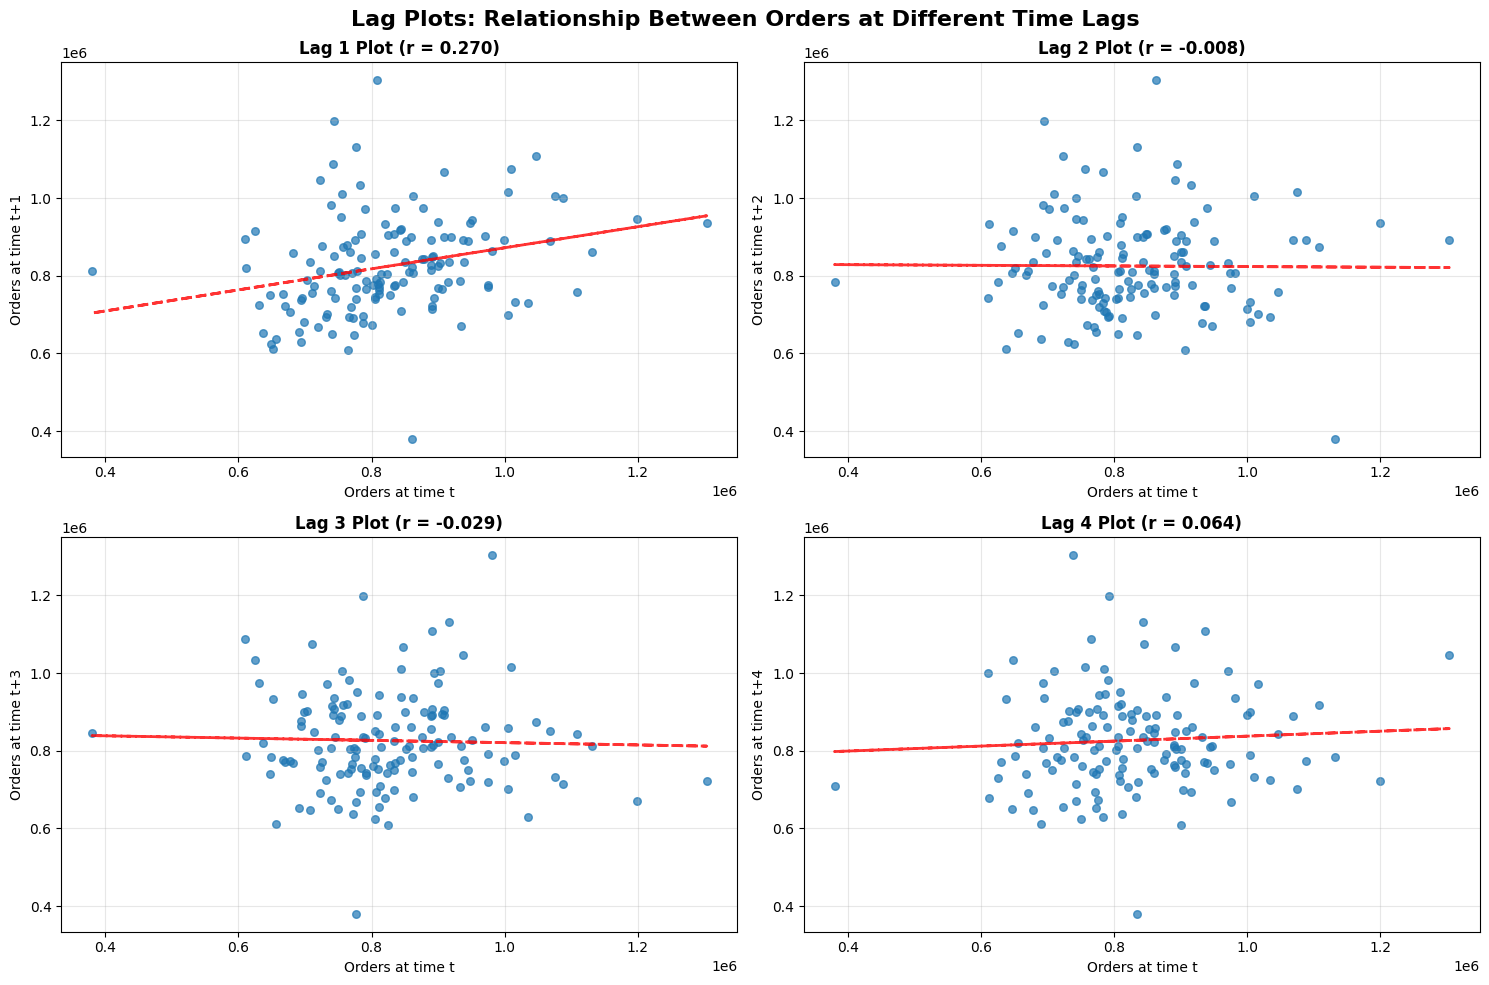


Creating ACF Plots...


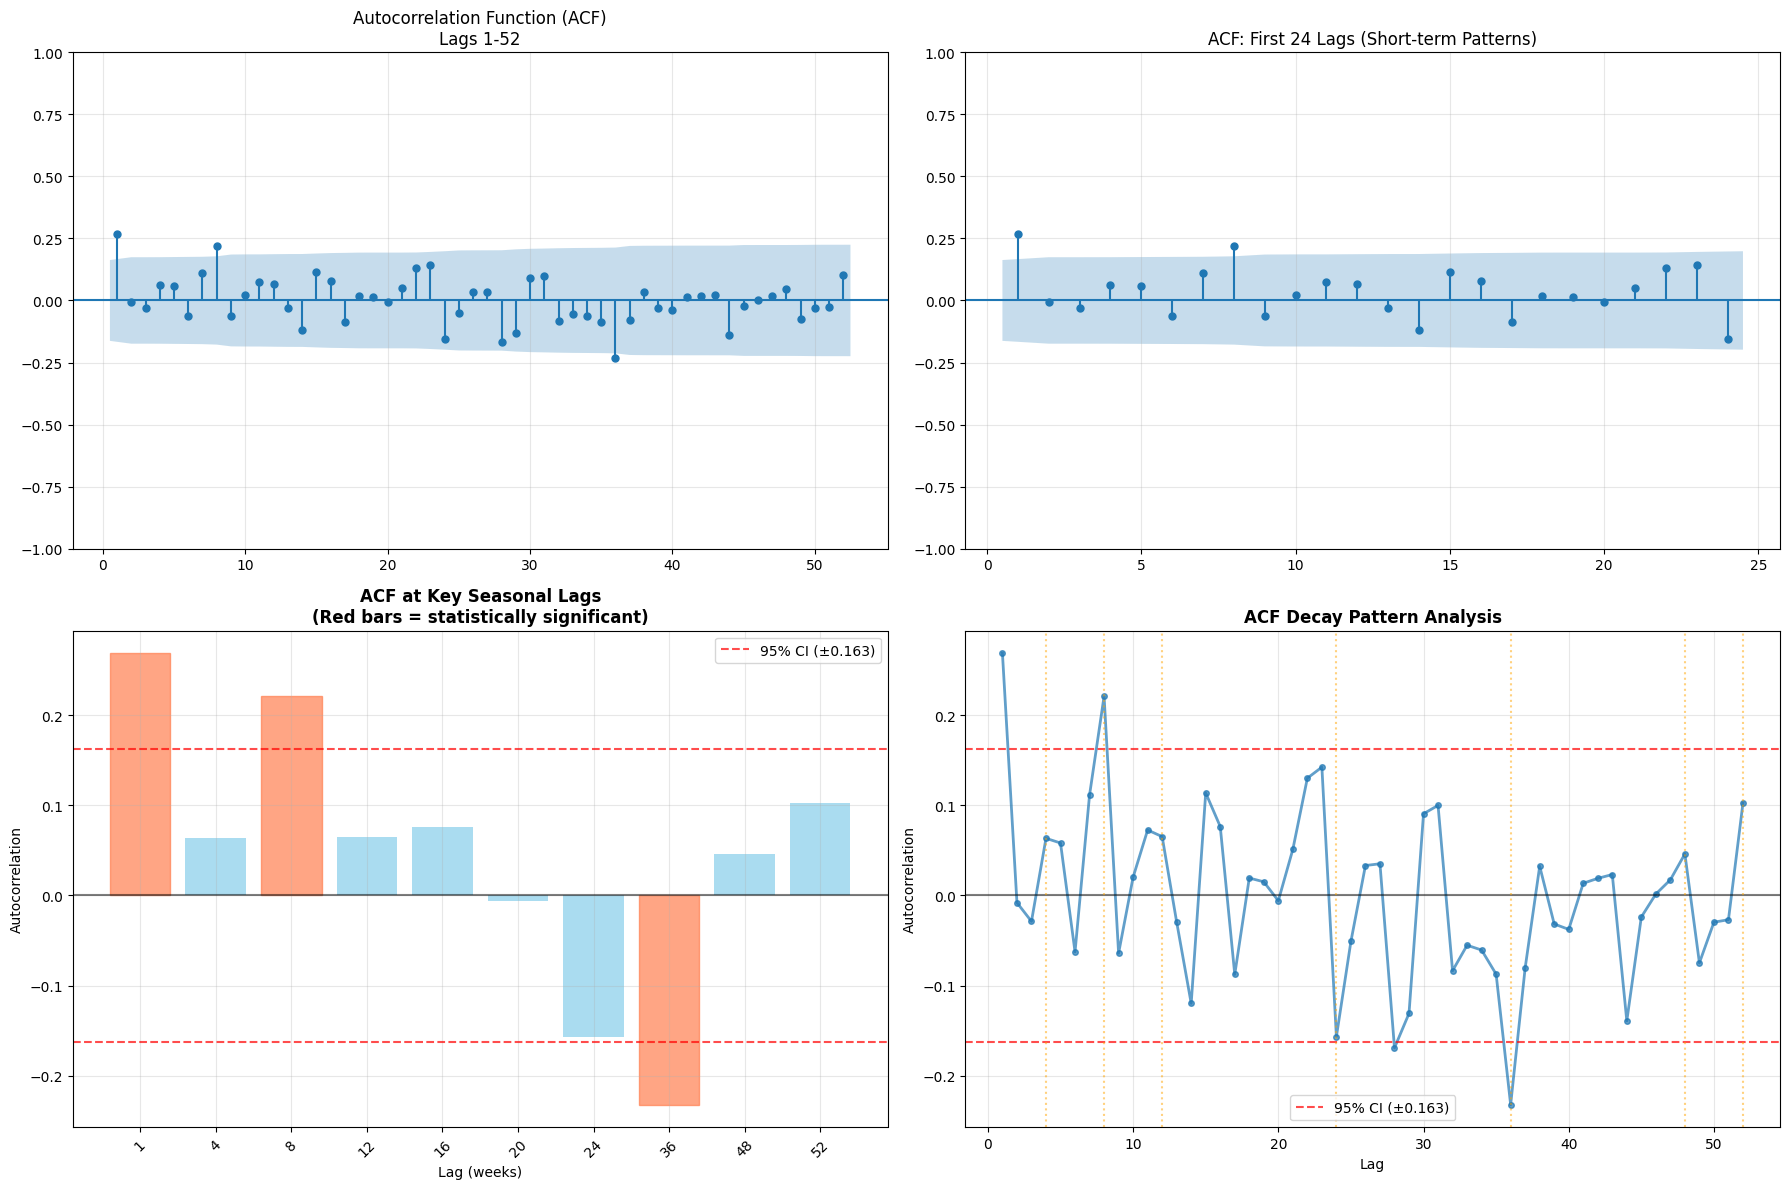


Creating PACF Plots...


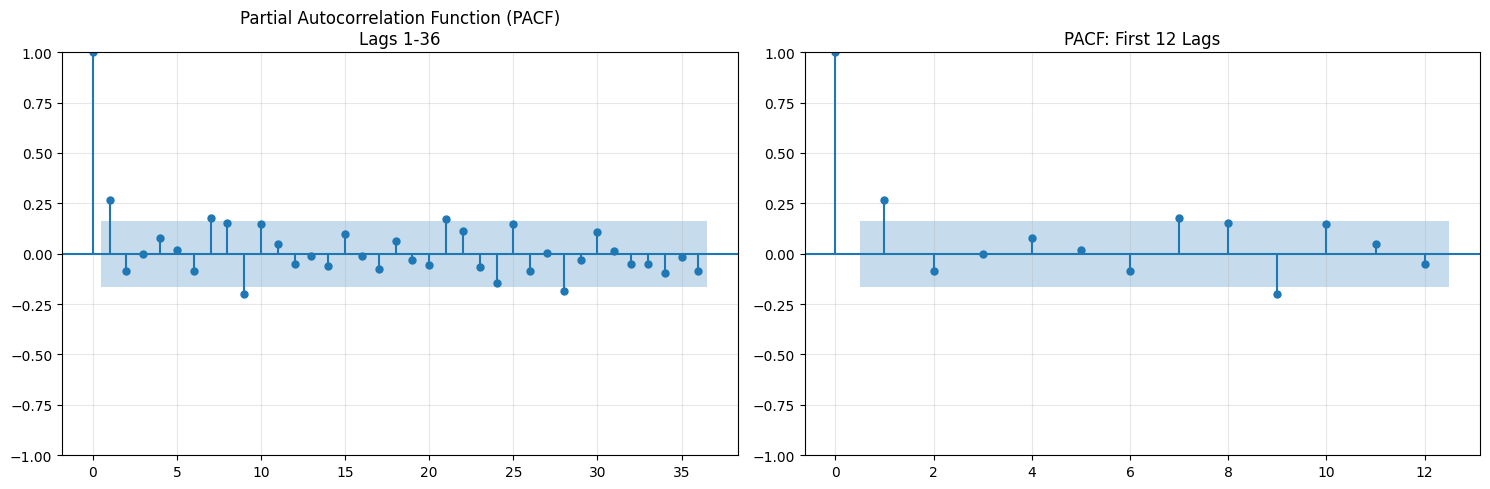


## 4. AUTOCORRELATION INTERPRETATION SUMMARY
AUTOCORRELATION ANALYSIS: KEY INSIGHTS

📈 TREND ANALYSIS:
• WEAK TREND: ACF decays quickly → More stationary series

🔄 SEASONALITY ANALYSIS:
• SEASONAL PATTERNS DETECTED at lags: [8, 36]
  - Lag 8: Bi-monthly pattern (ACF = 0.221)

⏱️  SHORT-TERM DEPENDENCIES:
• Significant short-term autocorrelations at lags: [1]
• Lag 1 correlation: 0.269 (Very strong if > 0.8)

📊 STATIONARITY ASSESSMENT:
• RELATIVELY STATIONARY: Few significant lags beyond confidence bounds

💡 MODELING RECOMMENDATIONS:
  1. Include seasonal components in model
  2. Include autoregressive terms (AR components)

📈 KEY STATISTICS:
• Series length: 145 observations
• Confidence bounds: ±0.163
• Significant ACF lags: 4 out of 52
• ACF decay ratio (lag10/lag1): 0.075


In [12]:
# Part 3: Autocorrelation Analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pandas.plotting import lag_plot
from statsmodels.tsa.stattools import acf

def create_autocorrelation_analysis(df, target_col='num_orders', lags=52):
    """
    Comprehensive autocorrelation analysis for time series data
    """
    
    # Prepare the time series data (aggregate by week)
    weekly_series = df.groupby('week')[target_col].sum()
    
    print("="*70)
    print("AUTOCORRELATION ANALYSIS")
    print("="*70)
    print(f"Time series length: {len(weekly_series)} weeks")
    print(f"Analysis lags: {lags} (up to 1 year for weekly data)")
    
    return weekly_series

# Prepare data for autocorrelation analysis
weekly_series = create_autocorrelation_analysis(train_df)

# 1. LAG PLOTS for different lag values
def create_lag_plots(series, max_lag=4, figsize=(15, 10)):
    """
    Create multiple lag plots to visualize autocorrelation at different lags
    """
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    axes = axes.flatten()
    
    print("\n## 1. LAG PLOTS ANALYSIS")
    print("Interpreting lag plots:")
    print("• Tight scatter along diagonal = Strong autocorrelation")
    print("• Circular/random scatter = Weak autocorrelation") 
    print("• Specific patterns = Non-linear relationships")
    
    for i, lag in enumerate(range(1, max_lag + 1)):
        plt.sca(axes[i])
        lag_plot(series, lag=lag, alpha=0.7, s=30)
        
        # Calculate correlation coefficient
        corr = series.corr(series.shift(lag))
        
        plt.title(f'Lag {lag} Plot (r = {corr:.3f})', fontweight='bold')
        plt.xlabel(f'Orders at time t')
        plt.ylabel(f'Orders at time t+{lag}')
        plt.grid(True, alpha=0.3)
        
        # Add trend line
        x = series[:-lag] if lag < len(series) else series
        y = series[lag:] if lag < len(series) else series
        
        if len(x) > 0 and len(y) > 0:
            z = np.polyfit(x, y, 1)
            p = np.poly1d(z)
            plt.plot(x, p(x), "r--", alpha=0.8, linewidth=2)
    
    plt.suptitle('Lag Plots: Relationship Between Orders at Different Time Lags', 
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return fig

print("\nCreating Lag Plots...")
lag_plots = create_lag_plots(weekly_series)

# 2. AUTOCORRELATION FUNCTION (ACF) PLOTS
def create_acf_analysis(series, lags=52, alpha=0.05):
    """
    Create comprehensive ACF analysis with multiple perspectives
    """
    fig = plt.figure(figsize=(18, 12))
    
    # 2.1 Standard ACF Plot
    plt.subplot(2, 2, 1)
    plot_acf(series, lags=lags, alpha=alpha, ax=plt.gca(), 
             title=f'Autocorrelation Function (ACF)\nLags 1-{lags}', 
             zero=False)
    plt.grid(True, alpha=0.3)
    
    # 2.2 ACF with different lag range to see patterns clearly
    plt.subplot(2, 2, 2)
    plot_acf(series, lags=24, alpha=alpha, ax=plt.gca(),
             title='ACF: First 24 Lags (Short-term Patterns)',
             zero=False)
    plt.grid(True, alpha=0.3)
    
    # 2.3 ACF for seasonal lags (focus on yearly pattern)
    plt.subplot(2, 2, 3)
    seasonal_lags = [1, 4, 8, 12, 16, 20, 24, 36, 48, 52]
    valid_lags = [lag for lag in seasonal_lags if lag <= lags]
    
    if valid_lags:
        acf_values = acf(series, nlags=max(valid_lags))
        seasonal_acf = [acf_values[lag] for lag in valid_lags]
        
        bars = plt.bar(range(len(valid_lags)), seasonal_acf, color='skyblue', alpha=0.7)
        plt.axhline(y=0, color='black', linestyle='-', alpha=0.5)
        
        # Add confidence intervals
        conf_bound = 1.96 / np.sqrt(len(series))
        plt.axhline(y=conf_bound, color='red', linestyle='--', alpha=0.7, 
                   label=f'95% CI (±{conf_bound:.3f})')
        plt.axhline(y=-conf_bound, color='red', linestyle='--', alpha=0.7)
        
        # Color significant bars
        for i, (lag, acf_val) in enumerate(zip(valid_lags, seasonal_acf)):
            if abs(acf_val) > conf_bound:
                bars[i].set_color('coral')
        
        plt.title('ACF at Key Seasonal Lags\n(Red bars = statistically significant)', 
                 fontweight='bold')
        plt.xlabel('Lag (weeks)')
        plt.ylabel('Autocorrelation')
        plt.xticks(range(len(valid_lags)), valid_lags, rotation=45)
        plt.legend()
        plt.grid(True, alpha=0.3)
    
    # 2.4 ACF Decay Analysis
    plt.subplot(2, 2, 4)
    all_acf_values = acf(series, nlags=lags)
    lags_range = range(1, lags + 1)
    
    plt.plot(lags_range, all_acf_values[1:], 'o-', alpha=0.7, linewidth=2, markersize=4)
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.5)
    
    # Add confidence interval
    conf_bound = 1.96 / np.sqrt(len(series))
    plt.axhline(y=conf_bound, color='red', linestyle='--', alpha=0.7, 
               label=f'95% CI (±{conf_bound:.3f})')
    plt.axhline(y=-conf_bound, color='red', linestyle='--', alpha=0.7)
    
    # Highlight seasonal lags
    seasonal_points = [4, 8, 12, 24, 36, 48, 52]
    for point in seasonal_points:
        if point <= lags:
            plt.axvline(x=point, color='orange', linestyle=':', alpha=0.5)
    
    plt.title('ACF Decay Pattern Analysis', fontweight='bold')
    plt.xlabel('Lag')
    plt.ylabel('Autocorrelation')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return all_acf_values

print("\nCreating ACF Plots...")
acf_values = create_acf_analysis(weekly_series, lags=52)

# 3. PARTIAL AUTOCORRELATION FUNCTION (PACF) PLOT
def create_pacf_analysis(series, lags=36):
    """
    Create PACF plot to identify direct relationships
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Full PACF
    plot_pacf(series, lags=lags, alpha=0.05, ax=ax1, 
              title=f'Partial Autocorrelation Function (PACF)\nLags 1-{lags}')
    ax1.grid(True, alpha=0.3)
    
    # First few lags for clarity
    plot_pacf(series, lags=min(12, lags), alpha=0.05, ax=ax2,
              title='PACF: First 12 Lags')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return fig

print("\nCreating PACF Plots...")
pacf_plots = create_pacf_analysis(weekly_series)

# 4. AUTOCORRELATION INTERPRETATION AND INSIGHTS
def generate_autocorrelation_insights(series, acf_values, lags=52):
    """
    Generate automated insights from autocorrelation analysis
    """
    print("="*70)
    print("AUTOCORRELATION ANALYSIS: KEY INSIGHTS")
    print("="*70)
    
    conf_bound = 1.96 / np.sqrt(len(series))
    
    # Trend Analysis
    print("\n📈 TREND ANALYSIS:")
    
    # Check if ACF decays slowly (indication of trend)
    lag_1_acf = acf_values[1]
    lag_10_acf = acf_values[10] if len(acf_values) > 10 else acf_values[-1]
    decay_ratio = abs(lag_10_acf / lag_1_acf) if lag_1_acf != 0 else 0
    
    if decay_ratio > 0.5:
        print("• STRONG TREND PRESENT: ACF decays slowly → Non-stationary series")
        print("  → Consider differencing for modeling")
    elif decay_ratio > 0.2:
        print("• MODERATE TREND: Some persistence in ACF")
    else:
        print("• WEAK TREND: ACF decays quickly → More stationary series")
    
    # Seasonality Analysis
    print("\n🔄 SEASONALITY ANALYSIS:")
    
    # Check for weekly seasonality (lag 4, 8, 12 ≈ monthly patterns)
    seasonal_lags = [4, 8, 12, 24, 36, 48, 52]
    significant_seasonal = []
    
    for lag in seasonal_lags:
        if lag < len(acf_values):
            if abs(acf_values[lag]) > conf_bound:
                significant_seasonal.append(lag)
    
    if significant_seasonal:
        print(f"• SEASONAL PATTERNS DETECTED at lags: {significant_seasonal}")
        
        # Interpret seasonal lags
        seasonal_interpretation = {
            4: "Possible monthly pattern (every 4 weeks)",
            8: "Bi-monthly pattern",
            12: "Quarterly pattern (every 12 weeks)", 
            24: "Half-yearly pattern",
            52: "Yearly seasonal pattern"
        }
        
        for lag in significant_seasonal[:3]:  # Top 3 most significant
            if lag in seasonal_interpretation:
                print(f"  - Lag {lag}: {seasonal_interpretation[lag]} (ACF = {acf_values[lag]:.3f})")
    else:
        print("• NO STRONG SEASONALITY: No significant patterns at common seasonal lags")
    
    # Short-term Dependencies
    print("\n⏱️  SHORT-TERM DEPENDENCIES:")
    
    significant_short_term = []
    for lag in range(1, min(6, len(acf_values))):
        if abs(acf_values[lag]) > conf_bound:
            significant_short_term.append(lag)
    
    if significant_short_term:
        print(f"• Significant short-term autocorrelations at lags: {significant_short_term}")
        print(f"• Lag 1 correlation: {acf_values[1]:.3f} (Very strong if > 0.8)")
    else:
        print("• Weak short-term dependencies")
    
    # Stationarity Assessment
    print("\n📊 STATIONARITY ASSESSMENT:")
    
    # Count significant lags beyond what we'd expect by chance
    significant_lags = sum(1 for acf_val in acf_values[1:] if abs(acf_val) > conf_bound)
    expected_random = 0.05 * len(acf_values[1:])  # 5% should be significant by chance
    
    if significant_lags > expected_random * 2:
        print(f"• NON-STATIONARY: {significant_lags} significant lags (expected ~{expected_random:.1f} by chance)")
        print("  → Series has time-dependent structure")
    else:
        print("• RELATIVELY STATIONARY: Few significant lags beyond confidence bounds")
    
    # Modeling Recommendations
    print("\n💡 MODELING RECOMMENDATIONS:")
    
    recommendations = []
    
    if decay_ratio > 0.5:
        recommendations.append("Use differencing (ARIMA) to handle trend")
    
    if significant_seasonal:
        recommendations.append("Include seasonal components in model")
        if 52 in significant_seasonal:
            recommendations.append("Consider seasonal ARIMA with period=52")
    
    if significant_short_term:
        recommendations.append("Include autoregressive terms (AR components)")
    
    if not recommendations:
        recommendations.append("Simple models may suffice - weak dependencies")
    
    for i, rec in enumerate(recommendations, 1):
        print(f"  {i}. {rec}")
    
    # Key Statistics
    print("\n📈 KEY STATISTICS:")
    print(f"• Series length: {len(series)} observations")
    print(f"• Confidence bounds: ±{conf_bound:.3f}")
    print(f"• Significant ACF lags: {significant_lags} out of {lags}")
    print(f"• ACF decay ratio (lag10/lag1): {decay_ratio:.3f}")

print("\n## 4. AUTOCORRELATION INTERPRETATION SUMMARY")
generate_autocorrelation_insights(weekly_series, acf_values, lags=52)

# 5. COMPARATIVE ACF ANALYSIS BY CATEGORY (Optional)
def compare_acf_by_category(df, top_categories=3, lags=24):
    """
    Compare ACF patterns across different meal categories
    """
    print("\n" + "="*70)
    print("COMPARATIVE ACF ANALYSIS BY MEAL CATEGORY")
    print("="*70)
    
    # Get top categories by total orders
    category_totals = df.groupby('category')['num_orders'].sum().nlargest(top_categories)
    top_cats = category_totals.index.tolist()
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flatten()
    
    for i, category in enumerate(top_cats):
        if i < len(axes):
            category_data = df[df['category'] == category]
            category_series = category_data.groupby('week')['num_orders'].sum()
            
            plot_acf(category_series, lags=lags, alpha=0.05, ax=axes[i],
                    title=f'ACF: {category}\n(Total: {category_totals[category]:,} orders)')
            axes[i].grid(True, alpha=0.3)
            
            # Calculate some stats
            if len(category_series) > 1:
                lag1_corr = category_series.corr(category_series.shift(1))
                print(f"• {category}: Lag-1 correlation = {lag1_corr:.3f}")
    
    plt.suptitle('Autocorrelation Patterns by Meal Category', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Uncomment to run category comparison
# print("\n## 5. CATEGORY-WISE ACF COMPARISON")
# compare_acf_by_category(train_df, top_categories=4)